### Simplified SpeechLM Pipeline Simulation

This script demonstrates a minimal implementation of speech tokenization and reconstruction, simulating core Speech Language Model components. It covers feature extraction, discrete token learning, and waveform synthesis from tokens.

Key Libraries Used:

    numpy: Signal generation and processing

    sklearn.cluster: K-means tokenization

    sounddevice: Audio playback

    plotly: Signal visualization

Code Logic and Flow

The simulation pipeline:

    Generates synthetic speech (440Hz + 880Hz tone)

    Segments audio into overlapping frames

    Extracts spectral magnitude features

    Learns discrete tokens via K-means

    Applies token transformation (mock LM)

    Synthesizes audio from tokens

    Compares original/reconstructed signals

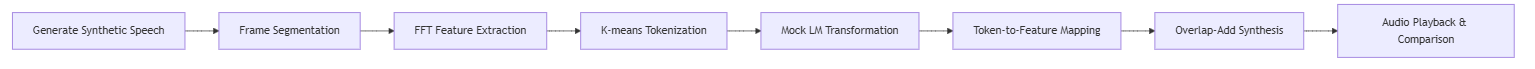

Step-by-Step Code Breakdown

1. Synthetic Speech Generation

    Creates 500ms dual-tone signal (440Hz + 880Hz)

    16kHz sample rate for speech-like processing

2. Frame Processing

    25ms frames (400 samples) with 50% overlap

    12.5ms hop size maintains temporal continuity

3. Feature Extraction

    Computes FFT magnitude spectrum per frame

    Uses only lower half (0-8kHz) as simplified "Mel-spectrogram"

    Captures spectral envelope information

4. Tokenization

    K-means clustering with 8 token vocabulary

    Learns prototypical spectral patterns

    Assigns discrete token IDs to frames

5. Mock Language Model

    Simple token transformation: repeats each token

    Simulates LM processing without actual modeling

6. Audio Synthesis

    Maps tokens back to cluster centroids

    Approximates inverse FFT for time-domain frames

    Overlap-add reconstruction with triangular windowing

    Normalization prevents clipping

7. Output & Evaluation

    Plays reconstructed audio

    Plots original vs reconstructed waveforms

    Saves visual comparison as PNG

Connecting to Lecture Concepts

This implementation demonstrates:

    Speech Tokenization: Converting continuous speech to discrete units

    Vector Quantization: K-means as basic tokenizer

    Frame-Based Processing: Standard 25ms windows with 50% overlap

    Spectral Features: FFT magnitude as simplified acoustic representation

    Vocabulary Size: 8 tokens shows extreme compression

    Token Synthesis: Reconstruction from discrete codes

    Overlap-Add Technique: Standard vocoder reconstruction method

    Synthesis Artifacts: Quality loss from tokenization and inverse FFT

    LM Simulation: Mock transformation shows token manipulation

    End-to-End Pipeline: From waveform → tokens → waveform

    Research Foundation: Mimics SoundStream/EnCodec tokenization

    Educational Value: Shows core concepts before complex implementations

    Compression Tradeoffs: Small vocabulary increases reconstruction error

    Real Speech Extension: Foundation for actual speech tokenization systems

In [3]:
import numpy as np
from sklearn.cluster import KMeans
import sounddevice as sd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Set default renderer to browser to avoid nbformat issues
pio.renderers.default = "browser"

# Parameters
fs = 16000  # Sampling frequency (Hz)
duration = 0.5  # Duration (seconds)
n_tokens = 8  # Number of discrete tokens (vocabulary size)
frame_length = 400  # Samples per frame (25ms at 16kHz)

# Step 1: Generate synthetic audio and extract features (speech tokenizer)
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
audio = np.sin(2 * np.pi * 440 * t) + 0.5 * np.sin(2 * np.pi * 880 * t)  # Synthetic signal
frames = np.array([audio[i:i+frame_length] for i in range(0, len(audio) - frame_length, frame_length // 2)])
features = np.abs(np.fft.fft(frames)[:, :frame_length // 2])  # Simplified "Mel-spectrogram"

# Step 2: Tokenize features using k-means
kmeans = KMeans(n_clusters=n_tokens, random_state=42)
tokens = kmeans.fit_predict(features)
token_centers = kmeans.cluster_centers_

# Step 3: Mock language model (simple transformation, e.g., repeat tokens)
transformed_tokens = np.repeat(tokens, 2)[:len(tokens)]  # Dummy transformation

# Step 4: Synthesize audio from tokens (vocoder)
reconstructed_features = token_centers[transformed_tokens]
reconstructed_audio = np.zeros(len(audio))
for i, frame in enumerate(reconstructed_features):
    start = i * (frame_length // 2)
    end = start + frame_length
    if end <= len(reconstructed_audio):
        # Inverse FFT approximation (simplified)
        # Pad to frame_length//2, then irfft to frame_length
        padded_frame = np.pad(frame, (0, frame_length//2 - len(frame)))
        frame_time = np.fft.irfft(padded_frame, n=frame_length)
        reconstructed_audio[start:end] += frame_time[:frame_length]

# Normalize and play
reconstructed_audio /= np.max(np.abs(reconstructed_audio))
sd.play(reconstructed_audio, fs)
sd.wait()

# Plot with Plotly
fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=("Original Audio", "Reconstructed Audio (Vocoder Output)"),
                    vertical_spacing=0.1)

# Add original audio trace
fig.add_trace(go.Scatter(x=t, y=audio, 
                        mode='lines', 
                        name='Original Audio',
                        line=dict(color='blue')), 
              row=1, col=1)

# Add reconstructed audio trace
fig.add_trace(go.Scatter(x=t, y=reconstructed_audio, 
                        mode='lines', 
                        name='Reconstructed Audio',
                        line=dict(color='red')), 
              row=2, col=1)

# Update layout
fig.update_layout(height=600, 
                  width=1000,
                  title_text="Speech LM Pipeline",
                  showlegend=False)

# Update x-axis labels
fig.update_xaxes(title_text="Time (s)", row=1, col=1)
fig.update_xaxes(title_text="Time (s)", row=2, col=1)

# Update y-axis labels
fig.update_yaxes(title_text="Amplitude", row=1, col=1)
fig.update_yaxes(title_text="Amplitude", row=2, col=1)

# Save as HTML (equivalent to savefig)
fig.write_html("speechlm_pipeline.html")

# Show the plot (equivalent to plt.show())
fig.show(renderer="browser")

### Here's a simple explanation of the code:

What it does: This code simulates a basic speech processing system that converts audio into "tokens" (like symbols), modifies them, and turns them back into sound.

Step-by-Step Breakdown:

    Make Test Sound:
    Creates a synthetic beep (440Hz + 880Hz tones) that lasts 0.5 seconds.

    Chop & Analyze Sound:

        Cuts the audio into small 25ms slices (called "frames")

        Converts each slice to a simplified frequency analysis (like seeing which musical notes are present)

    Convert to Tokens:
    Uses K-means clustering (a machine learning method) to group similar sound slices into 8 categories. Each category gets a number (token 0-7).

    Modify Tokens (Mock AI):
    Performs a dummy transformation - just repeats each token. In a real system, this could be like auto-completing speech or changing voice style.

    Turn Tokens Back to Sound:

        Uses the token numbers to look up their corresponding sound patterns

        Stitches these patterns back together into audio

        Plays the reconstructed sound

    Show Results:
    Plots both the original and reconstructed audio waves to compare them visually.

Key Idea: This is like a simplified version of how some AI speech systems work - breaking speech into manageable pieces, processing them as symbols, and reconstructing new audio.